#Retail Store Sales Performanance & Trend Analysis

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [14]:
np.random.seed(42)

data = {
    'Order_ID': range(1001, 1501),
    'Date': pd.date_range(start='2023-01-01', periods=500, freq='D'),
    'Product': np.random.choice(['Laptop','Mobile','TV',
                'T-Shirt','Jeans','Rice','Oil','Mixer'], 500),
    'Category': np.random.choice(['Electronics',
                'Clothing','Food'], 500),
    'Region': np.random.choice(['North','South',
                'East','West'], 500),
    'Quantity': np.random.randint(1, 20, 500),
    'Unit_Price': np.random.choice([500,1000,
                5000,50000,200,100], 500)
}

df = pd.DataFrame(data)
df['Revenue'] = df['Quantity'] * df['Unit_Price']
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Month_Name'] = df['Date'].dt.strftime('%B')

print("Data Created! Shape:", df.shape)
print(df.head())

Data Created! Shape: (500, 11)
   Order_ID       Date  Product     Category Region  Quantity  Unit_Price  \
0      1001 2023-01-01      Oil         Food  South         2         500   
1      1002 2023-01-02  T-Shirt  Electronics  North        17         100   
2      1003 2023-01-03    Jeans  Electronics   West        11         500   
3      1004 2023-01-04      Oil         Food   West        12       50000   
4      1005 2023-01-05       TV  Electronics   West        19         100   

   Revenue  Month  Year Month_Name  
0     1000      1  2023    January  
1     1700      1  2023    January  
2     5500      1  2023    January  
3   600000      1  2023    January  
4     1900      1  2023    January  


In [15]:
print("Missing Values:")
print(df.isnull().sum())

df.drop_duplicates(inplace=True)

print("Cleaning Done!")

Missing Values:
Order_ID      0
Date          0
Product       0
Category      0
Region        0
Quantity      0
Unit_Price    0
Revenue       0
Month         0
Year          0
Month_Name    0
dtype: int64
Cleaning Done!


In [16]:
print("====== BASIC STATS ======")
print(df.describe())
print("Total Revenue  :", df['Revenue'].sum())
print("Total Orders   :", df['Order_ID'].nunique())
print("Total Products :", df['Product'].nunique())
print("Regions        :", df['Region'].unique())

====== BASIC STATS ======
          Order_ID                 Date    Quantity  Unit_Price  \
count   500.000000                  500  500.000000    500.0000   
mean   1250.500000  2023-09-07 12:00:00   10.170000   9683.2000   
min    1001.000000  2023-01-01 00:00:00    1.000000    100.0000   
25%    1125.750000  2023-05-05 18:00:00    5.000000    200.0000   
50%    1250.500000  2023-09-07 12:00:00   10.000000    500.0000   
75%    1375.250000  2024-01-10 06:00:00   15.000000   5000.0000   
max    1500.000000  2024-05-14 00:00:00   19.000000  50000.0000   
std     144.481833                  NaN    5.552906  18586.6739   

             Revenue       Month         Year  
count     500.000000  500.000000   500.000000  
mean    95980.600000    5.508000  2023.270000  
min       100.000000    1.000000  2023.000000  
25%      1775.000000    3.000000  2023.000000  
50%      6500.000000    5.000000  2023.000000  
75%     35000.000000    8.000000  2024.000000  
max    950000.000000   12.000000  

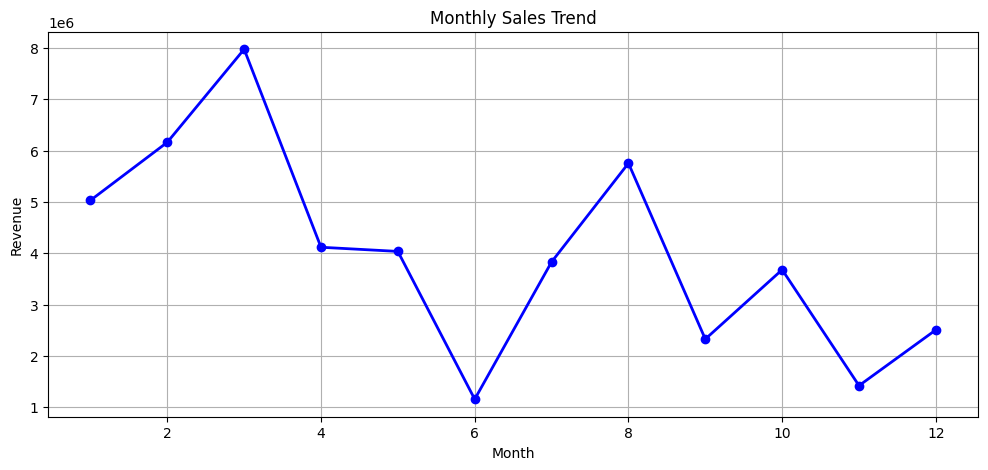

In [17]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values,
         marker='o', color='blue', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

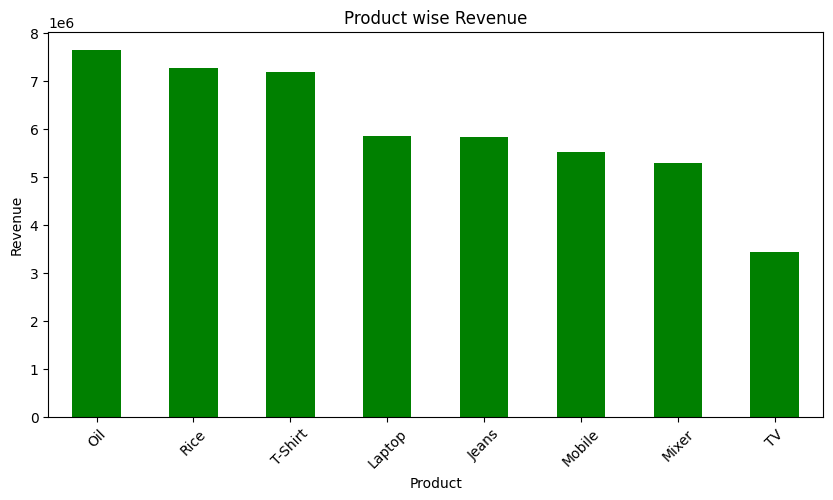

In [18]:
top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar', color='green')
plt.title('Product wise Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

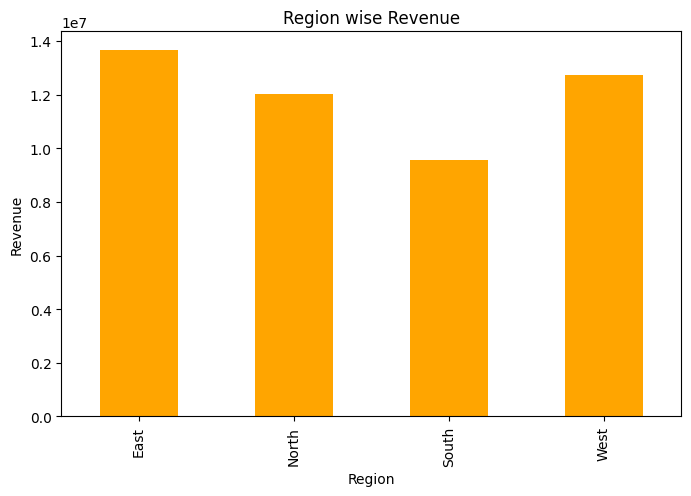

In [19]:
region_sales = df.groupby('Region')['Revenue'].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar', color='orange')
plt.title('Region wise Revenue')
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.show()

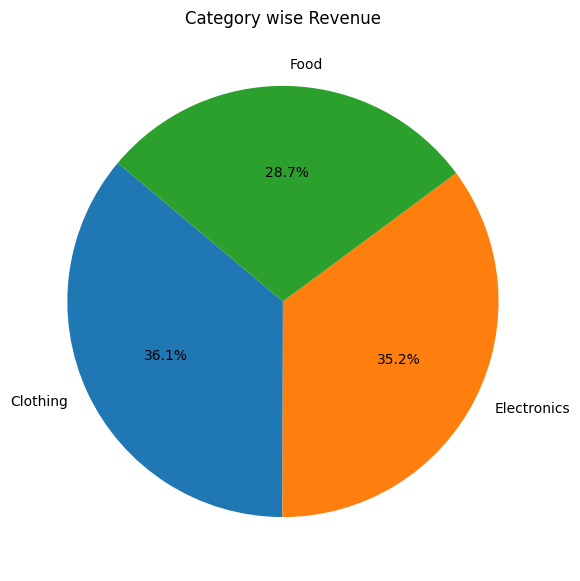

In [20]:
category_sales = df.groupby('Category')['Revenue'].sum()

plt.figure(figsize=(7,7))
plt.pie(category_sales,
        labels=category_sales.index,
        autopct='%1.1f%%',
        startangle=140)
plt.title('Category wise Revenue')
plt.show()

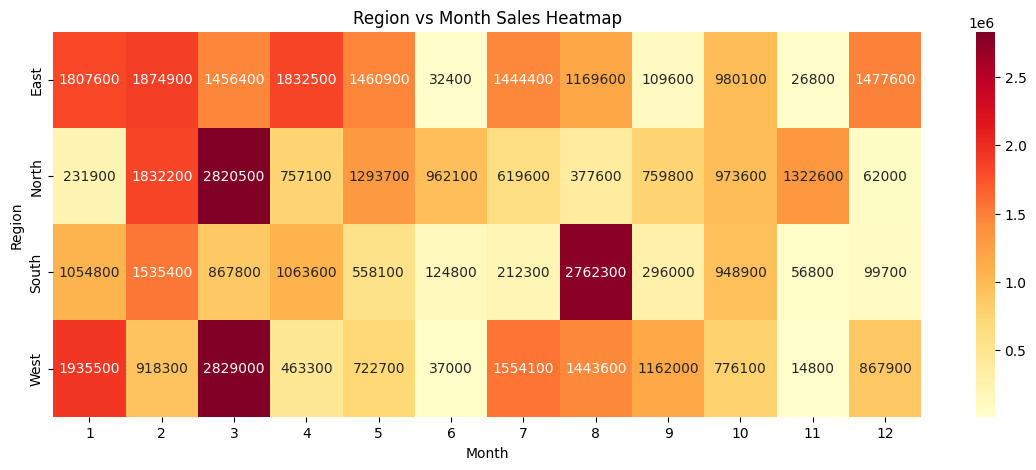

In [21]:
pivot = df.pivot_table(values='Revenue',
                       index='Region',
                       columns='Month',
                       aggfunc='sum')

plt.figure(figsize=(14,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Region vs Month Sales Heatmap')
plt.show()

In [22]:
print("========== FINAL SUMMARY ==========")
print("Total Revenue  :", df['Revenue'].sum())
print("Best Month     :", df.groupby('Month_Name')['Revenue'].sum().idxmax())
print("Top Product    :", df.groupby('Product')['Revenue'].sum().idxmax())
print("Best Region    :", df.groupby('Region')['Revenue'].sum().idxmax())
print("Top Category   :", df.groupby('Category')['Revenue'].sum().idxmax())
print("====================================")

========== FINAL SUMMARY ==========
Total Revenue  : 47990300
Best Month     : March
Top Product    : Oil
Best Region    : East
Top Category   : Clothing
